In [64]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
TW_1000= pd.read_csv(
    "../classification/Twitter/Relative_labeling/sigma=1000/Twitter-Relative-Sigma-1000.data",
    sep=",",
    header=None
)

groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = []
for group in groups:
    for t in range(7):
        columns.append(f"{group}_{t}")

columns.append("label") 

TW_1000.columns = columns

In [4]:
### Choose minor class for expedition
df_1 = TW_1000[TW_1000["label"] == 1]

### Basic Statistic

In [6]:
cols_ncd = [col for col in TW_1000.columns if "NCD" in col]

df_1[cols_ncd].describe().T

,count,mean,std,min,25%,50%,75%,max
NCD_0,1177.0,2294.503823,2928.627493,16.0,321.0,1102.0,3289.0,24210.0
NCD_1,1177.0,2080.596432,2770.389015,0.0,290.0,854.0,2960.0,22899.0
NCD_2,1177.0,2136.076466,2725.585370,0.0,316.0,1097.0,2945.0,20495.0
NCD_3,1177.0,2323.086661,2893.515164,0.0,364.0,1431.0,3130.0,27007.0
NCD_4,1177.0,2600.023789,3098.656883,0.0,474.0,1562.0,3506.0,30957.0
NCD_5,1177.0,3019.030586,3525.184473,0.0,683.0,1773.0,4076.0,28603.0
NCD_6,1177.0,3925.300765,4066.326029,67.0,1477.0,2374.0,4876.0,37505.0


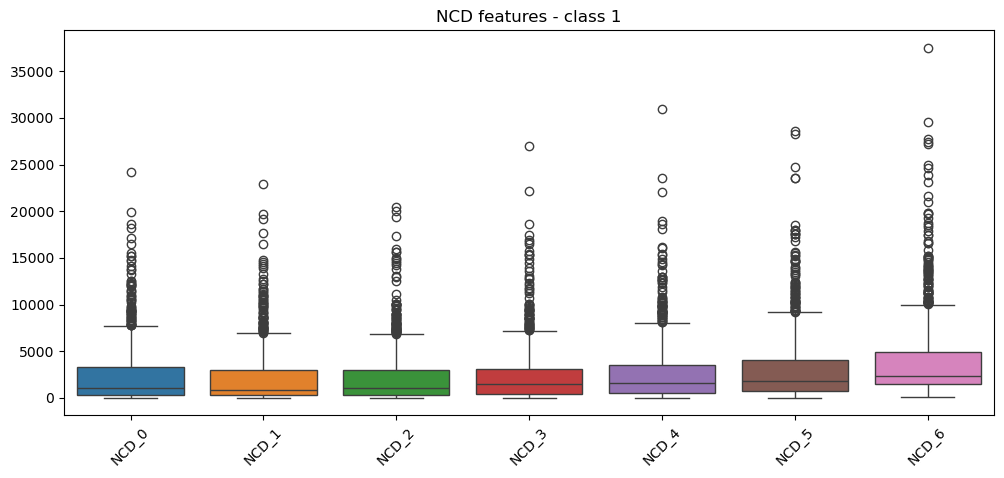

In [7]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_ncd])
plt.xticks(rotation=45)
plt.title("NCD features - class 1")
plt.show()

In [8]:
cols_ai = [col for col in TW_1000.columns if "AI" in col]

df_1[cols_ai].describe().T

,count,mean,std,min,25%,50%,75%,max
AI_0,1177.0,888.134240,1211.258325,7.0,188.0,430.0,1105.0,15105.0
AI_1,1177.0,800.366185,1158.185087,0.0,167.0,355.0,964.0,15730.0
AI_2,1177.0,846.470688,1180.734863,0.0,185.0,418.0,1058.0,16389.0
AI_3,1177.0,943.654206,1241.095406,0.0,204.0,522.0,1203.0,17445.0
AI_4,1177.0,1064.003398,1300.693349,0.0,253.0,694.0,1359.0,18654.0
AI_5,1177.0,1232.256585,1466.069240,0.0,332.0,891.0,1504.0,22035.0
AI_6,1177.0,1709.671198,1890.399831,9.0,788.0,1193.0,2014.0,29402.0


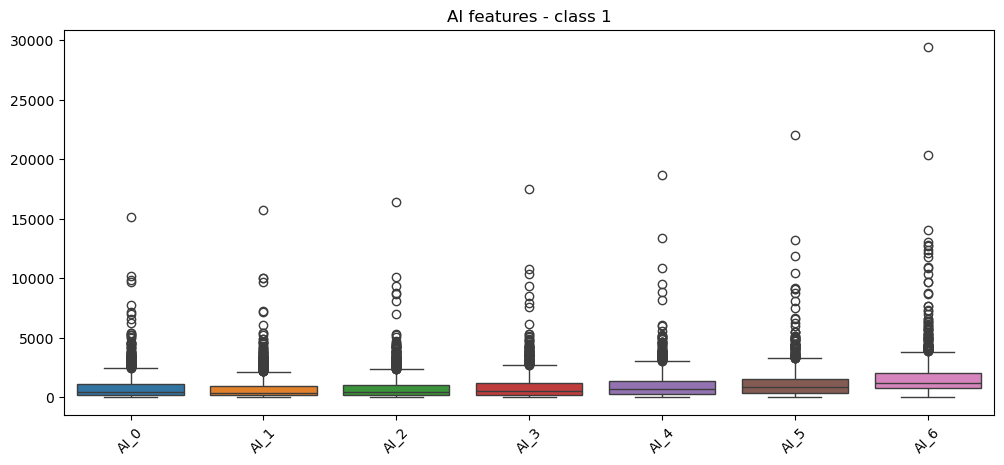

In [9]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_ai])
plt.xticks(rotation=45)
plt.title("AI features - class 1")
plt.show()

In [10]:
cols_as_na = [col for col in TW_1000.columns if "AS(NA)" in col]

df_1[cols_as_na].describe().T

,count,mean,std,min,25%,50%,75%,max
AS(NA)_0,1177.0,0.002934,0.003231,0.000024,0.000800,0.001910,0.004056,0.024997
AS(NA)_1,1177.0,0.002754,0.003149,0.000000,0.000713,0.001689,0.003775,0.022498
AS(NA)_2,1177.0,0.002867,0.003192,0.000000,0.000855,0.001830,0.003809,0.023815
AS(NA)_3,1177.0,0.002881,0.003215,0.000000,0.000914,0.001851,0.003850,0.025091
AS(NA)_4,1177.0,0.003023,0.003259,0.000000,0.001025,0.002009,0.003952,0.026851
AS(NA)_5,1177.0,0.003309,0.003576,0.000000,0.001187,0.002150,0.004274,0.029403
AS(NA)_6,1177.0,0.003707,0.003792,0.000104,0.001466,0.002419,0.004755,0.040258


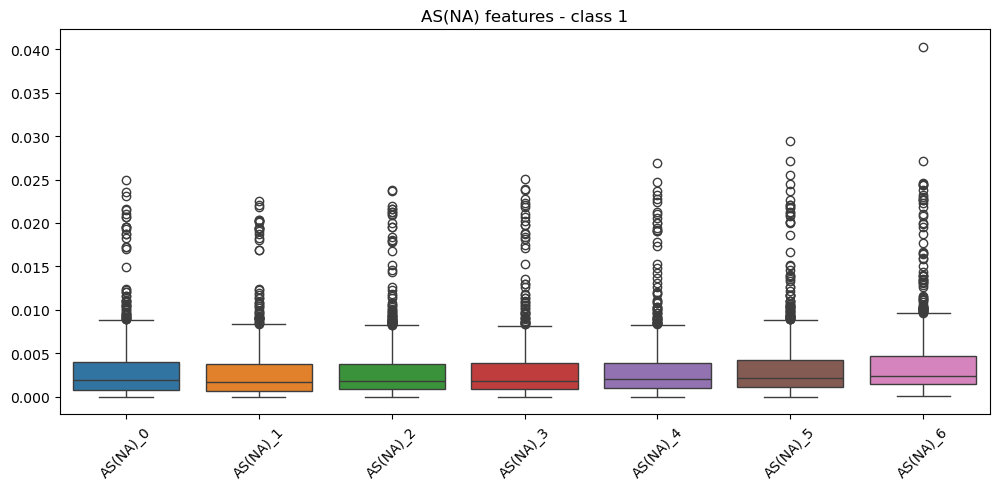

In [11]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_as_na])
plt.xticks(rotation=45)
plt.title("AS(NA) features - class 1")
plt.show()

In [12]:
cols_bl = [col for col in TW_1000.columns if "BL" in col]

df_1[cols_bl].describe().T

,count,mean,std,min,25%,50%,75%,max
BL_0,1177.0,0.998423,0.003613,0.952381,0.998220,1.0,1.0,1.0
BL_1,1177.0,0.978167,0.141233,0.000000,0.998456,1.0,1.0,1.0
BL_2,1177.0,0.991771,0.082156,0.000000,0.998621,1.0,1.0,1.0
BL_3,1177.0,0.992600,0.076897,0.000000,0.998748,1.0,1.0,1.0
BL_4,1177.0,0.995331,0.058220,0.000000,0.998594,1.0,1.0,1.0
BL_5,1177.0,0.997008,0.041240,0.000000,0.998561,1.0,1.0,1.0
BL_6,1177.0,0.998938,0.002122,0.982587,0.998810,1.0,1.0,1.0


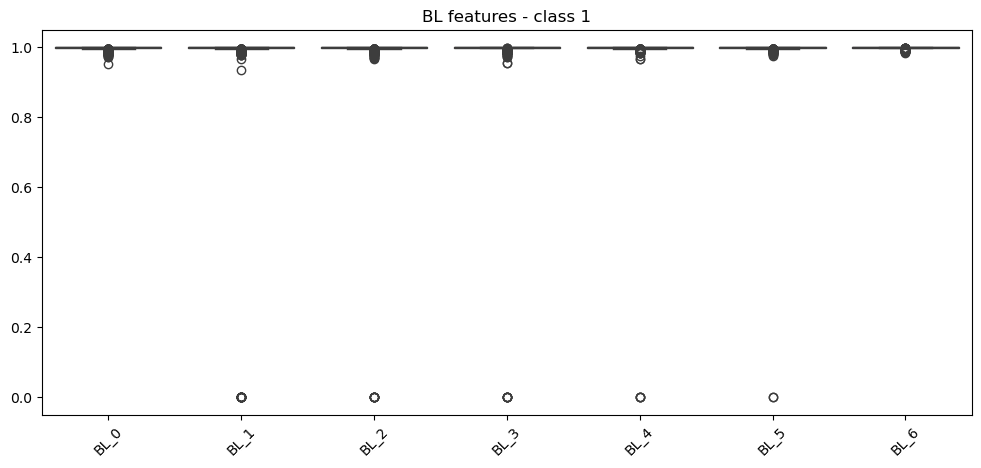

In [13]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_bl])
plt.xticks(rotation=45)
plt.title("BL features - class 1")
plt.show()

In [14]:
cols_nac = [col for col in TW_1000.columns if "NAC_" in col]

df_1[cols_nac].describe().T

,count,mean,std,min,25%,50%,75%,max
NAC_0,1177.0,2394.265930,3070.293811,16.0,327.0,1160.0,3381.0,26644.0
NAC_1,1177.0,2161.885302,2878.895554,0.0,291.0,900.0,3048.0,25228.0
NAC_2,1177.0,2217.347494,2844.595509,0.0,320.0,1139.0,3057.0,22065.0
NAC_3,1177.0,2414.042481,3035.878710,0.0,379.0,1469.0,3261.0,30592.0
NAC_4,1177.0,2704.041631,3246.544819,0.0,477.0,1603.0,3633.0,35089.0
NAC_5,1177.0,3135.272727,3667.151257,0.0,714.0,1830.0,4168.0,32289.0
NAC_6,1177.0,4061.502124,4206.093815,73.0,1500.0,2487.0,5141.0,37505.0


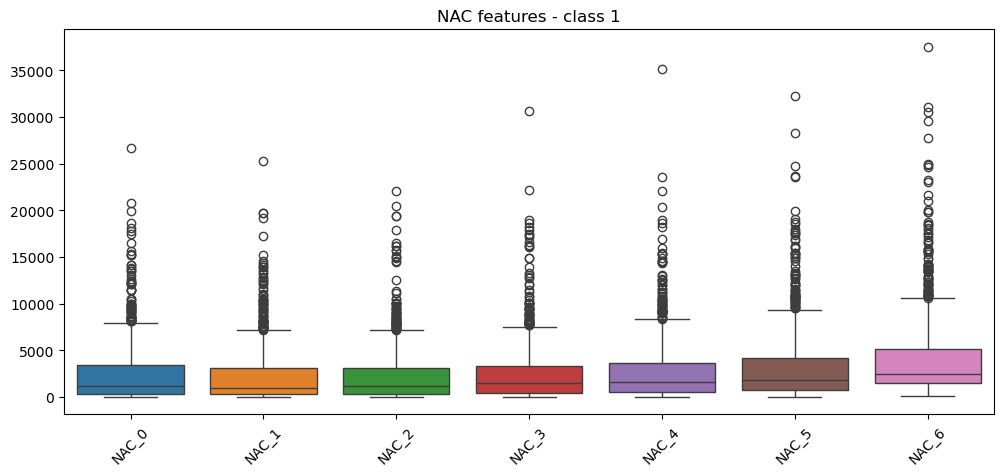

In [15]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_nac])
plt.xticks(rotation=45)
plt.title("NAC features - class 1")
plt.show()

In [16]:
cols_as_nac = [col for col in TW_1000.columns if "AS(NAC)" in col]

df_1[cols_as_nac].describe().T

,count,mean,std,min,25%,50%,75%,max
AS(NAC)_0,1177.0,0.001814,0.002147,0.000011,0.000418,0.001102,0.002418,0.021422
AS(NAC)_1,1177.0,0.001722,0.002165,0.000000,0.000376,0.000961,0.002317,0.022498
AS(NAC)_2,1177.0,0.001785,0.002128,0.000000,0.000450,0.001063,0.002300,0.014694
AS(NAC)_3,1177.0,0.001792,0.002098,0.000000,0.000494,0.001088,0.002352,0.014062
AS(NAC)_4,1177.0,0.001870,0.002114,0.000000,0.000559,0.001155,0.002491,0.015133
AS(NAC)_5,1177.0,0.002033,0.002303,0.000000,0.000656,0.001214,0.002707,0.021327
AS(NAC)_6,1177.0,0.002287,0.002427,0.000060,0.000757,0.001425,0.002945,0.022478


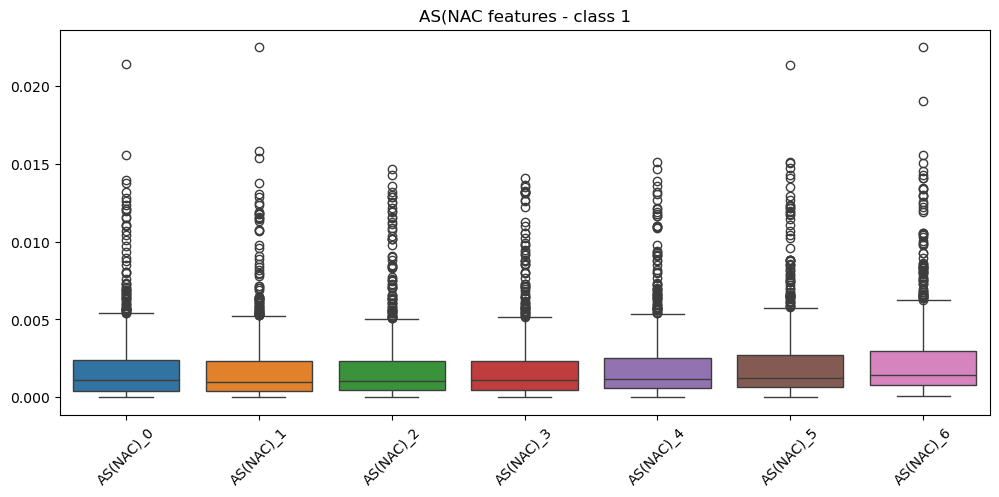

In [17]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_as_nac])
plt.xticks(rotation=45)
plt.title("AS(NAC features - class 1")
plt.show()

In [18]:
cols_cs = [col for col in TW_1000.columns if "CS" in col]

df_1[cols_cs].describe().T

,count,mean,std,min,25%,50%,75%,max
CS_0,1177.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
CS_1,1177.0,0.979609,0.141393,0.0,1.0,1.0,1.0,1.0
CS_2,1177.0,0.993203,0.082198,0.0,1.0,1.0,1.0,1.0
CS_3,1177.0,0.994053,0.076922,0.0,1.0,1.0,1.0,1.0
CS_4,1177.0,0.996602,0.058222,0.0,1.0,1.0,1.0,1.0
CS_5,1177.0,0.998301,0.041204,0.0,1.0,1.0,1.0,1.0
CS_6,1177.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


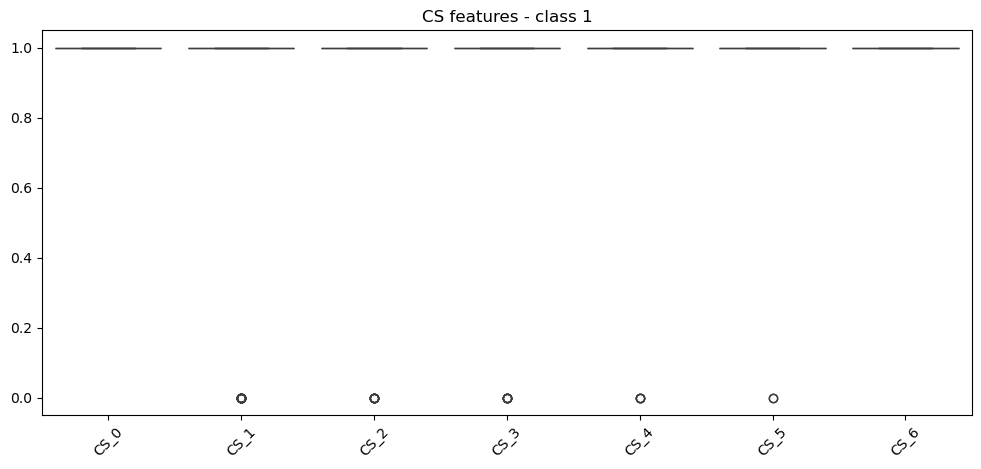

In [19]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_cs])
plt.xticks(rotation=45)
plt.title("CS features - class 1")
plt.show()

In [20]:
cols_at = [col for col in TW_1000.columns if "AT" in col]

df_1[cols_at].describe().T

,count,mean,std,min,25%,50%,75%,max
AT_0,1177.0,1.052507,0.172575,1.0,1.0,1.0,1.048809,4.338855
AT_1,1177.0,1.037940,0.355397,0.0,1.0,1.0,1.037374,7.531157
AT_2,1177.0,1.046050,0.262374,0.0,1.0,1.0,1.039576,6.099768
AT_3,1177.0,1.046267,0.255958,0.0,1.0,1.0,1.040350,6.460591
AT_4,1177.0,1.051168,0.234515,0.0,1.0,1.0,1.043085,6.492500
AT_5,1177.0,1.055455,0.280595,0.0,1.0,1.0,1.044135,7.784616
AT_6,1177.0,1.047531,0.158431,1.0,1.0,1.0,1.044251,3.695219


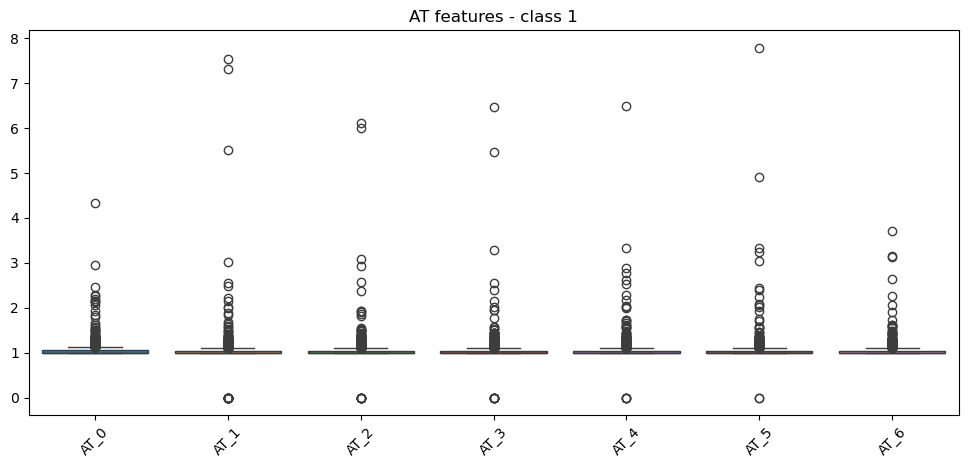

In [21]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_at])
plt.xticks(rotation=45)
plt.title("AT features - class 1")
plt.show()

In [22]:
cols_na = [col for col in TW_1000.columns if "NA_" in col]

df_1[cols_na].describe().T

,count,mean,std,min,25%,50%,75%,max
NA_0,1177.0,1776.926083,2254.879003,16.0,294.0,925.0,2449.0,21723.0
NA_1,1177.0,1593.615973,2097.872266,0.0,265.0,761.0,2265.0,20594.0
NA_2,1177.0,1645.237893,2121.373995,0.0,282.0,874.0,2260.0,18800.0
NA_3,1177.0,1789.905692,2242.802612,0.0,328.0,1143.0,2353.0,24156.0
NA_4,1177.0,1988.107901,2339.069133,0.0,417.0,1345.0,2615.0,28133.0
NA_5,1177.0,2295.614274,2607.601938,0.0,584.0,1508.0,2988.0,26705.0
NA_6,1177.0,2995.266780,3063.146771,59.0,1299.0,1977.0,3669.0,34085.0


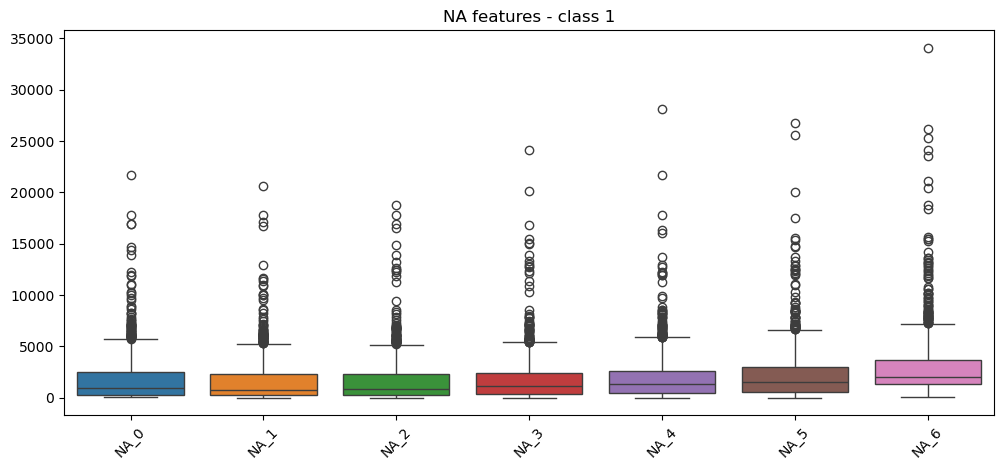

In [23]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_na])
plt.xticks(rotation=45)
plt.title("NA features - class 1")
plt.show()

In [25]:
cols_adl = [col for col in TW_1000.columns if "ADL" in col]

df_1[cols_adl].describe().T

,count,mean,std,min,25%,50%,75%,max
ADL_0,1177.0,1.069506,0.194230,1.0,1.0,1.0,1.070858,4.368976
ADL_1,1177.0,1.053400,0.366671,0.0,1.0,1.0,1.053785,7.590505
ADL_2,1177.0,1.061924,0.274913,0.0,1.0,1.0,1.057285,6.143851
ADL_3,1177.0,1.062931,0.269506,0.0,1.0,1.0,1.058491,6.519704
ADL_4,1177.0,1.068029,0.250214,0.0,1.0,1.0,1.067243,6.545000
ADL_5,1177.0,1.071695,0.292475,0.0,1.0,1.0,1.060981,7.849231
ADL_6,1177.0,1.061719,0.172514,1.0,1.0,1.0,1.062831,3.698207


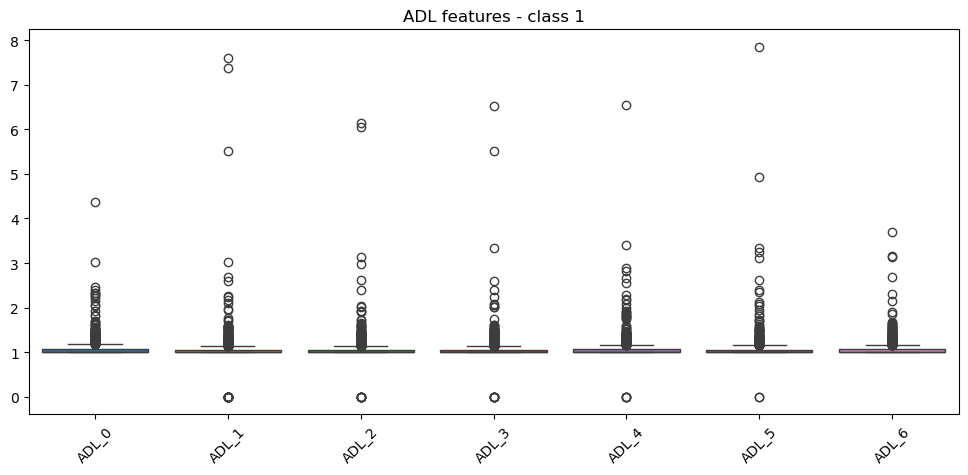

In [26]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_adl])
plt.xticks(rotation=45)
plt.title("ADL features - class 1")
plt.show()

In [27]:
cols_nad = [col for col in TW_1000.columns if "NAD" in col]

df_1[cols_nad].describe().T

,count,mean,std,min,25%,50%,75%,max
NAD_0,1177.0,2298.468989,2933.490515,16.0,321.0,1105.0,3289.0,24301.0
NAD_1,1177.0,2083.581138,2774.067080,0.0,290.0,856.0,2964.0,22980.0
NAD_2,1177.0,2138.806287,2729.100275,0.0,316.0,1103.0,2947.0,20495.0
NAD_3,1177.0,2326.100255,2897.373203,0.0,365.0,1433.0,3130.0,27071.0
NAD_4,1177.0,2603.425658,3102.521458,0.0,475.0,1563.0,3507.0,31028.0
NAD_5,1177.0,3022.861512,3529.144027,0.0,690.0,1776.0,4076.0,28697.0
NAD_6,1177.0,3929.582838,4070.129802,67.0,1478.0,2374.0,4887.0,37505.0


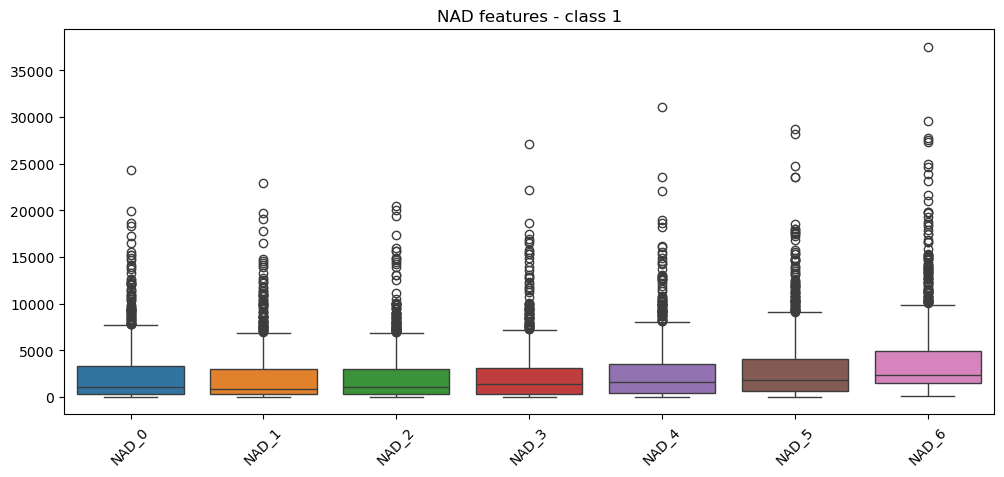

In [28]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_1[cols_nad])
plt.xticks(rotation=45)
plt.title("NAD features - class 1")
plt.show()

In [29]:
def outlier_ratio(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).mean()

outliers = df_1.apply(outlier_ratio)
outliers.sort_values(ascending=False).head(20)

ADL_1    0.163976
BL_3     0.163127
BL_1     0.158029
AT_1     0.157179
BL_2     0.149533
ADL_3    0.141886
BL_5     0.139337
ADL_2    0.138488
BL_4     0.135939
AT_2     0.132540
AT_3     0.130841
BL_6     0.129142
BL_0     0.128292
ADL_5    0.127443
AT_4     0.125743
ADL_4    0.118946
AT_5     0.115548
AT_0     0.114698
ADL_6    0.111300
ADL_0    0.109601
dtype: float64

### Clustering analysis of the minority class

In [31]:
cols = [col for col in TW_1000.columns if any(x in col for x in ["NCD", "AI", "NA"])]

In [32]:
df_1 = TW_1000[TW_1000["label"] == 1].copy()
X = df_1[cols]

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_1["cluster"] = clusters

In [37]:
df_1["cluster"].value_counts()

cluster
0    859
1    290
2     28
Name: count, dtype: int64

In [38]:
df_1.groupby("cluster")[cols].mean()

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,AI_0,AI_1,AI_2,...,NA_4,NA_5,NA_6,NAD_0,NAD_1,NAD_2,NAD_3,NAD_4,NAD_5,NAD_6
cluster,,,,,,,,,,,,,,,,,,,,,
0,961.463329,829.530850,922.009313,1059.291036,1215.236321,1432.422584,2135.285215,411.525029,353.353900,408.686845,...,987.536671,1162.224680,1751.287544,963.349243,830.811409,923.200233,1060.684517,1216.736903,1434.164144,2137.201397
1,5160.986207,4821.403448,4784.155172,5057.117241,5613.237931,6453.586207,7686.551724,1876.303448,1743.165517,1754.427586,...,4117.724138,4701.500000,5503.934483,5168.755172,4827.831034,4789.841379,5063.103448,5620.475862,6461.506897,7695.282759
2,13501.714286,12074.571429,11955.392857,12777.785714,13875.035714,16121.714286,19884.607143,5275.214286,4749.357143,4873.214286,...,10627.464286,12148.285714,15176.142857,13530.071429,12094.178571,11974.714286,12799.714286,13897.035714,16147.285714,19915.392857


### The 3-class Random Forest model

In [40]:
df_new = TW_1000.copy()
df_new.loc[df_new["label"] == 1, "new_label"] = df_1["cluster"].values + 1
df_new.loc[df_new["label"] == 0, "new_label"] = 0
df_new["new_label"] = df_new["new_label"].astype(int)

In [41]:
df_new["new_label"].value_counts()

new_label
0    139530
1       859
2       290
3        28
Name: count, dtype: int64

In [43]:
X = df_new.drop(columns=["label", "new_label"])
y = df_new["new_label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27906
           1       0.90      0.41      0.56       172
           2       0.69      0.47      0.56        58
           3       1.00      0.83      0.91         6

    accuracy                           0.99     28142
   macro avg       0.90      0.68      0.76     28142
weighted avg       0.99      0.99      0.99     28142



### The 3-class Random Forest model with SMOTE

In [46]:
X = df_new.drop(columns=["label", "new_label"])
y = df_new["new_label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
pd.Series(y_res).value_counts()

new_label
0    111624
1    111624
2    111624
3    111624
Name: count, dtype: int64

In [49]:
model = RandomForestClassifier(random_state=42)
model.fit(X_res, y_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     27906
           1       0.52      0.66      0.58       172
           2       0.55      0.97      0.70        58
           3       1.00      1.00      1.00         6

    accuracy                           0.99     28142
   macro avg       0.77      0.90      0.82     28142
weighted avg       0.99      0.99      0.99     28142



### 2-stage Random Forest model

In [51]:
df_new = TW_1000.copy()
df_new.loc[df_new["label"] == 1, "new_label"] = df_1["cluster"].values + 1
df_new.loc[df_new["label"] == 0, "new_label"] = 0

df_new["new_label"] = df_new["new_label"].astype(int)

In [52]:
df_stage1 = df_new.copy()
df_stage1["buzz"] = (df_stage1["new_label"] > 0).astype(int)

In [53]:
X = df_stage1.drop(columns=["label", "new_label", "buzz"])
y_stage1 = df_stage1["buzz"]
y_stage2 = df_stage1["new_label"]

In [54]:
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split( X, y_stage1, y_stage2, test_size=0.2, random_state=42, stratify=y_stage1)

In [55]:
model_stage1 = RandomForestClassifier(class_weight="balanced", random_state=42)
model_stage1.fit(X_train, y1_train)

y1_pred = model_stage1.predict(X_test)

print("STAGE 1 RESULTS:")
print(classification_report(y1_test, y1_pred))

STAGE 1 RESULTS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27907
           1       0.80      0.44      0.57       235

    accuracy                           0.99     28142
   macro avg       0.90      0.72      0.78     28142
weighted avg       0.99      0.99      0.99     28142



In [56]:
mask_train = y2_train > 0
X2_train = X_train[mask_train]
y2_train_filtered = y2_train[mask_train]

In [57]:
sm = SMOTE(k_neighbors=3, random_state=42)
X2_res, y2_res = sm.fit_resample(X2_train, y2_train_filtered)

In [58]:
model_stage2 = RandomForestClassifier(random_state=42)
model_stage2.fit(X2_res, y2_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
buzz_idx = np.where(y1_pred == 1)[0]
X2_test_subset = X_test.iloc[buzz_idx]

In [63]:
y2_pred_subset = model_stage2.predict(X2_test_subset)
final_pred = np.zeros(len(X_test), dtype=int)
final_pred[buzz_idx] = y2_pred_subset

print("FINAL 2-STAGE RESULTS:")
print(classification_report(y2_test, final_pred))

FINAL 2-STAGE RESULTS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27907
           1       0.90      0.43      0.58       168
           2       0.61      0.46      0.52        61
           3       1.00      0.67      0.80         6

    accuracy                           0.99     28142
   macro avg       0.88      0.64      0.73     28142
weighted avg       0.99      0.99      0.99     28142



### The 3-class XGBoost model

In [65]:
df_model = df_new.copy()
df_model["NCD_trend"] = df_model["NCD_6"] - df_model["NCD_0"]
df_model["AI_trend"] = df_model["AI_6"] - df_model["AI_0"]
df_model["NA_trend"] = df_model["NA_6"] - df_model["NA_0"]


df_model["NCD_ratio"] = df_model["NCD_6"] / (df_model["NCD_0"] + 1)

In [66]:
X = df_model.drop(columns=["label", "new_label"])
y = df_model["new_label"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)

In [67]:
sm = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(pd.Series(y_res).value_counts())

new_label
0    111624
1    111624
2    111624
3    111624
Name: count, dtype: int64


### Different n_estimators

In [68]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    n_jobs=-1
)

model.fit(X_res, y_res)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [69]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     27906
           1       0.42      0.73      0.53       172
           2       0.55      0.95      0.70        58
           3       1.00      1.00      1.00         6

    accuracy                           0.99     28142
   macro avg       0.74      0.92      0.81     28142
weighted avg       0.99      0.99      0.99     28142



In [70]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    n_jobs=-1
)

model.fit(X_res, y_res)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [71]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     27906
           1       0.29      0.77      0.42       172
           2       0.54      0.97      0.69        58
           3       1.00      1.00      1.00         6

    accuracy                           0.99     28142
   macro avg       0.71      0.93      0.78     28142
weighted avg       0.99      0.99      0.99     28142



In [72]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    n_jobs=-1
)

model.fit(X_res, y_res)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     27906
           1       0.49      0.69      0.57       172
           2       0.56      0.93      0.70        58
           3       1.00      1.00      1.00         6

    accuracy                           0.99     28142
   macro avg       0.76      0.90      0.82     28142
weighted avg       0.99      0.99      0.99     28142



In [74]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    n_jobs=-1
)

model.fit(X_res, y_res)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [75]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27906
           1       0.54      0.65      0.59       172
           2       0.59      0.93      0.72        58
           3       1.00      1.00      1.00         6

    accuracy                           0.99     28142
   macro avg       0.78      0.89      0.83     28142
weighted avg       0.99      0.99      0.99     28142



### The 3-class XGBOOST without feature engeeniring

In [76]:
X = df_new.drop(columns=["label", "new_label"])
y = df_new["new_label"]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [78]:
sm = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [79]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    n_jobs=-1
)

model.fit(X_res, y_res)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [80]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     27906
           1       0.50      0.67      0.58       172
           2       0.57      0.93      0.71        58
           3       1.00      1.00      1.00         6

    accuracy                           0.99     28142
   macro avg       0.77      0.90      0.82     28142
weighted avg       0.99      0.99      0.99     28142

